# FS1 + FS2 流量传感器 — 双回路物理建模
Hydraulic Systems Dataset | 10 Hz 采样 | 2205 周期 × 600 点/周期 | 15 MB 总大小

- **FS1**: 主工作回路，0~20.5 l/min，变化剧烈 | **FS2**: 冷却回路，8.8~10.5 l/min，近乎恒流
- **创新点**: FS1-FS2 差值建模、FS2 作为异常检测器、液压功率/效率物理量交叉验证

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fft, signal, stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import os, gc, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

DATA_DIR = r'd:/for HS/dataset'
print('Libraries loaded.')

Libraries loaded.


## 模块 1：双传感器数据概览
FS1 vs FS2 的基本特征对比。

In [2]:
# Load both sensors + profile
profile = pd.read_csv(os.path.join(DATA_DIR, 'profile.txt'), sep='\t', header=None)
profile.columns = ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator', 'Stable']

fs1 = pd.read_csv(os.path.join(DATA_DIR, 'FS1.txt'), sep='\t', header=None)
fs2 = pd.read_csv(os.path.join(DATA_DIR, 'FS2.txt'), sep='\t', header=None)

print(f'FS1: {fs1.shape[0]} cycles × {fs1.shape[1]} pts | range=[{fs1.values.min():.2f}, {fs1.values.max():.2f}] l/min')
print(f'FS2: {fs2.shape[0]} cycles × {fs2.shape[1]} pts | range=[{fs2.values.min():.2f}, {fs2.values.max():.2f}] l/min')
print(f'Corr(FS1_mean, FS2_mean) per cycle: {np.corrcoef(fs1.mean(axis=1), fs2.mean(axis=1))[0,1]:.4f}')

# FS2 'constancy' check: per-cycle std
fs2_std = fs2.std(axis=1)
print(f'\nFS2 per-cycle std: [{fs2_std.min():.4f}, {fs2_std.max():.4f}] l/min')
print(f'  → FS2 is {"nearly constant" if fs2_std.max() < 0.2 else "variable"} across cycles')

fault_config = {
    'Cooler':       {100:'正常', 20:'降低', 3:'失效'},
    'Valve':        {100:'正常', 90:'轻微滞后', 80:'严重滞后', 73:'近失效'},
    'Pump_Leakage': {0:'无泄漏', 1:'轻微泄漏', 2:'严重泄漏'},
    'Accumulator':  {130:'正常130bar', 115:'微降115', 100:'严重100', 90:'近失效90'},
}

# FS1 per-fault mean overview
print('\n=== FS1 (主回路) per-fault mean flow ===')
for col, labels in fault_config.items():
    print(f'  {col}:')
    for val, name in labels.items():
        mask = profile[col] == val
        if mask.sum() > 0:
            print(f'    {name}: {fs1[mask].values.mean():.2f} l/min (n={mask.sum()})')

print('\n=== FS2 (冷却回路) per-fault mean flow ===')
for col, labels in fault_config.items():
    print(f'  {col}:')
    for val, name in labels.items():
        mask = profile[col] == val
        if mask.sum() > 0:
            print(f'    {name}: {fs2[mask].values.mean():.2f} l/min')

FS1: 2205 cycles × 600 pts | range=[0.00, 20.48] l/min
FS2: 2205 cycles × 600 pts | range=[8.76, 10.45] l/min
Corr(FS1_mean, FS2_mean) per cycle: 0.5454

FS2 per-cycle std: [0.0124, 0.0918] l/min
  → FS2 is nearly constant across cycles

=== FS1 (主回路) per-fault mean flow ===
  Cooler:
    正常: 6.58 l/min (n=741)
    降低: 6.54 l/min (n=732)
    失效: 5.47 l/min (n=732)
  Valve:
    正常: 6.41 l/min (n=1125)
    轻微滞后: 5.99 l/min (n=360)
    严重滞后: 5.99 l/min (n=360)
    近失效: 5.95 l/min (n=360)
  Pump_Leakage:
    无泄漏: 6.60 l/min (n=1221)
    轻微泄漏: 5.79 l/min (n=492)
    严重泄漏: 5.61 l/min (n=492)
  Accumulator:
    正常130bar: 6.52 l/min (n=599)
    微降115: 5.95 l/min (n=399)


    严重100: 5.78 l/min (n=399)
    近失效90: 6.29 l/min (n=808)

=== FS2 (冷却回路) per-fault mean flow ===
  Cooler:
    正常: 10.16 l/min
    降低: 9.66 l/min
    失效: 9.12 l/min
  Valve:
    正常: 9.67 l/min
    轻微滞后: 9.63 l/min
    严重滞后: 9.63 l/min
    近失效: 9.63 l/min
  Pump_Leakage:
    无泄漏: 9.67 l/min
    轻微泄漏: 9.62 l/min
    严重泄漏: 9.64 l/min
  Accumulator:
    正常130bar: 9.57 l/min
    微降115: 9.63 l/min
    严重100: 9.60 l/min
    近失效90: 9.74 l/min


## 模块 2：特征工程
- FS1 + FS2 各自的 30 特征（复用 extract_features）
- **FS1-FS2 差值**的 30 特征（创新：流量差反映内部泄漏）
- **液压功率**特征（加载 PS1 降采样后算 FS1×PS1）
- **系统效率**特征（液压功率 / 电机功率）

In [3]:
def extract_features(row, fs=10):
    """Extract 30 features from one 600-point flow cycle at 10 Hz."""
    x = row.values if hasattr(row, 'values') else np.asarray(row, dtype=np.float64)
    n = len(x)
    feats = {}
    
    # Time-domain (10)
    feats['mean']   = np.mean(x)
    feats['std']    = np.std(x)
    feats['max']    = np.max(x)
    feats['min']    = np.min(x)
    feats['range']  = feats['max'] - feats['min']
    feats['rms']    = np.sqrt(np.mean(x**2))
    feats['crest']  = np.max(np.abs(x)) / feats['rms'] if feats['rms'] > 0 else 0
    feats['skew']   = sp_stats.skew(x)
    feats['kurt']   = sp_stats.kurtosis(x)
    feats['median'] = np.median(x)
    
    # 6-segment stats (12) — each segment = 100 pts = 10s
    seg_len = n // 6
    for s in range(6):
        seg = x[s*seg_len:(s+1)*seg_len]
        feats[f'seg{s+1}_mean'] = np.mean(seg)
        feats[f'seg{s+1}_std']  = np.std(seg)
    
    # Frequency domain (4) — Nyquist = 5 Hz
    yf = fft.fft(x)
    xf = fft.fftfreq(n, d=1/fs)
    half = n // 2
    xf_half = xf[:half]
    amp = np.abs(yf[:half]) / n * 2
    
    dom_idx = np.argmax(amp[1:]) + 1
    feats['dom_freq'] = xf_half[dom_idx]
    feats['dom_amp']  = amp[dom_idx]
    
    total_power = np.sum(amp**2)
    if total_power > 0:
        feats['lf_ratio'] = np.sum(amp[(xf_half>=0.05)&(xf_half<1)]**2) / total_power
        feats['mf_ratio'] = np.sum(amp[(xf_half>=1)&(xf_half<3)]**2) / total_power
        feats['hf_ratio'] = np.sum(amp[(xf_half>=3)&(xf_half<=5)]**2) / total_power
    else:
        feats['lf_ratio'] = feats['mf_ratio'] = feats['hf_ratio'] = 0.0
    
    # Peak features (3)
    prominence = max(0.05 * np.std(x), 1e-6)
    peaks, _ = signal.find_peaks(x, distance=20, prominence=prominence)
    feats['n_peaks'] = len(peaks)
    feats['peak_mean_h'] = np.mean(x[peaks]) if len(peaks) > 0 else 0.0
    feats['peak_mean_gap'] = np.mean(np.diff(peaks)) if len(peaks) > 1 else 0.0
    
    # Extra: cycle total flow volume (l) = integral of l/min * (1/60) min per sample
    feats['total_volume'] = np.sum(x) / fs / 60  # total liters in this cycle
    
    return pd.Series(feats)

print('extract_features() defined for 10 Hz data.')

extract_features() defined for 10 Hz data.


In [4]:
print('Extracting FS1 features...')
fs1_feats = fs1.apply(extract_features, axis=1)
print(f'  FS1: {fs1_feats.shape[1]} features')

print('Extracting FS2 features...')
fs2_feats = fs2.apply(extract_features, axis=1)
print(f'  FS2: {fs2_feats.shape[1]} features')

print('Extracting FS1-FS2 difference features...')
fs_diff = fs1 - fs2
diff_feats = fs_diff.apply(extract_features, axis=1)
diff_feats.columns = ['diff_'+c for c in diff_feats.columns]
print(f'  Diff: {diff_feats.shape[1]} features')

# Physical fusion: hydraulic power = FS1 × PS1 (downsampled)
print('\nComputing hydraulic power features (FS1 × PS1)...')
ps1 = pd.read_csv(os.path.join(DATA_DIR, 'PS1.txt'), sep='\t', header=None)
# Downsample PS1 from 6000 (100Hz) to 600 (10Hz) by 10-pt mean
ps1_ds = ps1.values.reshape(2205, 600, 10).mean(axis=2)  # (2205, 600)
# Downsample FS1 similarly (FS1 is already 10Hz, just use values)
fs1_vals = fs1.values.astype(np.float64)
# Hydraulic power proxy (relative units: l/min × bar)
hyd_power = fs1_vals * ps1_ds  # (2205, 600)

hyd_feats = pd.DataFrame({
    'hyd_mean': hyd_power.mean(axis=1),
    'hyd_std':  hyd_power.std(axis=1),
    'hyd_max':  hyd_power.max(axis=1),
    'hyd_total': hyd_power.sum(axis=1),  # cumulative hydraulic energy proxy
})
print(f'  Hydraulic power: {hyd_feats.shape[1]} features')

# Efficiency: hydraulic power / motor power
print('Computing efficiency features (hydraulic / motor power)...')
eps1 = pd.read_csv(os.path.join(DATA_DIR, 'EPS1.txt'), sep='\t', header=None)
eps1_ds = eps1.values.reshape(2205, 600, 10).mean(axis=2)  # (2205, 600)
motor_power_mean = eps1_ds.mean(axis=1)  # per-cycle mean motor power
efficiency = hyd_power.mean(axis=1) / motor_power_mean  # hydraulic/electrical

eff_feats = pd.DataFrame({
    'efficiency': efficiency,
})
print(f'  Efficiency: {eff_feats.shape[1]} feature')

del ps1, eps1, ps1_ds, eps1_ds, hyd_power; gc.collect()

# Combine all features
X_fs1 = fs1_feats.copy()
X_fs2 = fs2_feats.copy()
X_fs1.columns = ['FS1_'+c for c in X_fs1.columns]
X_fs2.columns = ['FS2_'+c for c in X_fs2.columns]

X_combined = pd.concat([X_fs1, X_fs2, diff_feats, hyd_feats, eff_feats], axis=1)
print(f'\nTotal combined features: {X_combined.shape[1]}')

# Downsampled curves for waveform plots
ds_curves = {}  # {sensor: {fault: {state: {'mean':..., 'std':...}}}}
for sensor_name, sensor_df in [('FS1', fs1), ('FS2', fs2), ('FS1-FS2', fs_diff)]:
    ds_curves[sensor_name] = {}
    for fault_col, labels in fault_config.items():
        ds_curves[sensor_name][fault_col] = {}
        for state in labels:
            mask = profile[fault_col] == state
            if mask.sum() > 0:
                raw = sensor_df[mask].values.astype(np.float64)
                ds_curves[sensor_name][fault_col][state] = {
                    'mean': raw.mean(axis=0),
                    'std':  raw.std(axis=0)
                }


Extracting FS1 features...


  FS1: 31 features
Extracting FS2 features...


  FS2: 31 features
Extracting FS1-FS2 difference features...


  Diff: 31 features

Computing hydraulic power features (FS1 × PS1)...


  Hydraulic power: 4 features
Computing efficiency features (hydraulic / motor power)...


  Efficiency: 1 feature

Total combined features: 98


## 模块 3：四组实验 — 分类能力对比
A: FS1 单独 | B: FS2 单独 | C: FS1+FS2 | D: 全部融合（含差值和液压功率）

In [5]:
target_config = {
    'Cooler': [3, 20, 100], 'Valve': [73, 80, 90, 100],
    'Pump_Leakage': [0, 1, 2], 'Accumulator': [90, 100, 115, 130],
}

# Build experiment groups
fs1_feats_clean = X_fs1.copy()
fs2_feats_clean = X_fs2.copy()
fs12_feats = pd.concat([X_fs1, X_fs2], axis=1)

experiments = {
    'A: FS1 only': fs1_feats_clean,
    'B: FS2 only': fs2_feats_clean,
    'C: FS1+FS2': fs12_feats,
    'D: Full fusion': X_combined,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results = {}  # {experiment: {fault: f1}}

print('Classification F1 (5CV Random Forest):')
print(f'{"Experiment":<20}', end='')
for t in target_config:
    print(f'{t:<16}', end='')
print()
print('-' * 84)

for exp_name, X_exp in experiments.items():
    all_results[exp_name] = {}
    print(f'{exp_name:<20}', end='')
    for fault_col, classes in target_config.items():
        valid_mask = profile[fault_col].isin(classes).values  # convert to numpy bool array
        X_sub = X_exp.values[valid_mask]
        y_raw = profile[fault_col].values[valid_mask]
        le = LabelEncoder()
        y_enc = le.fit_transform(y_raw)
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        scores = cross_val_score(rf, X_sub, y_enc, cv=cv, scoring='f1_weighted')
        all_results[exp_name][fault_col] = scores.mean()
        print(f'{scores.mean():.4f}           ', end='')
    print()

# Compute gains
print('\nFusion gain (D - A):')
for t in target_config:
    gain = all_results['D: Full fusion'][t] - all_results['A: FS1 only'][t]
    print(f'  {t:<14}: {all_results["A: FS1 only"][t]:.4f} → {all_results["D: Full fusion"][t]:.4f} ({gain:+.4f})')

Classification F1 (5CV Random Forest):
Experiment          Cooler          Valve           Pump_Leakage    Accumulator     
------------------------------------------------------------------------------------
A: FS1 only         

0.9932           

0.9845           

0.9928           

0.9651           
B: FS2 only         

...

0.9800           
D: Full fusion      

0.9968           

0.9827           

0.9959           

0.9773           

Fusion gain (D - A):
  Cooler        : 0.9932 → 0.9968 (+0.0036)
  Valve         : 0.9845 → 0.9827 (-0.0018)
  Pump_Leakage  : 0.9928 → 0.9959 (+0.0032)
  Accumulator   : 0.9651 → 0.9773 (+0.0122)


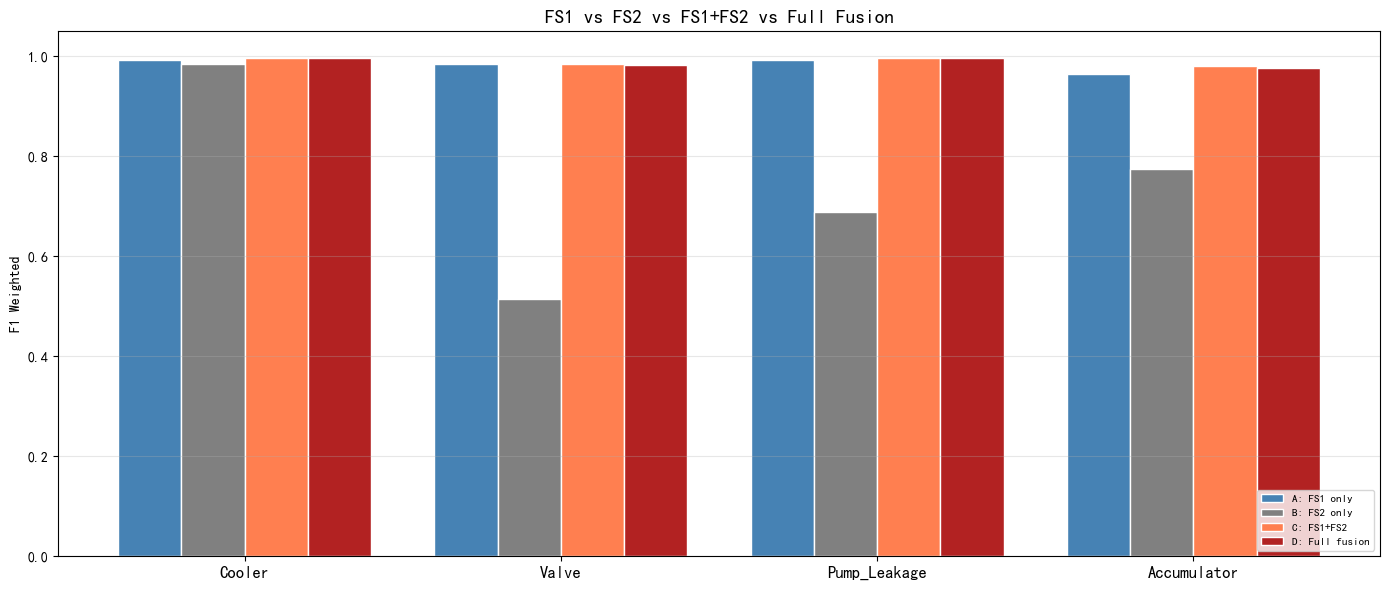

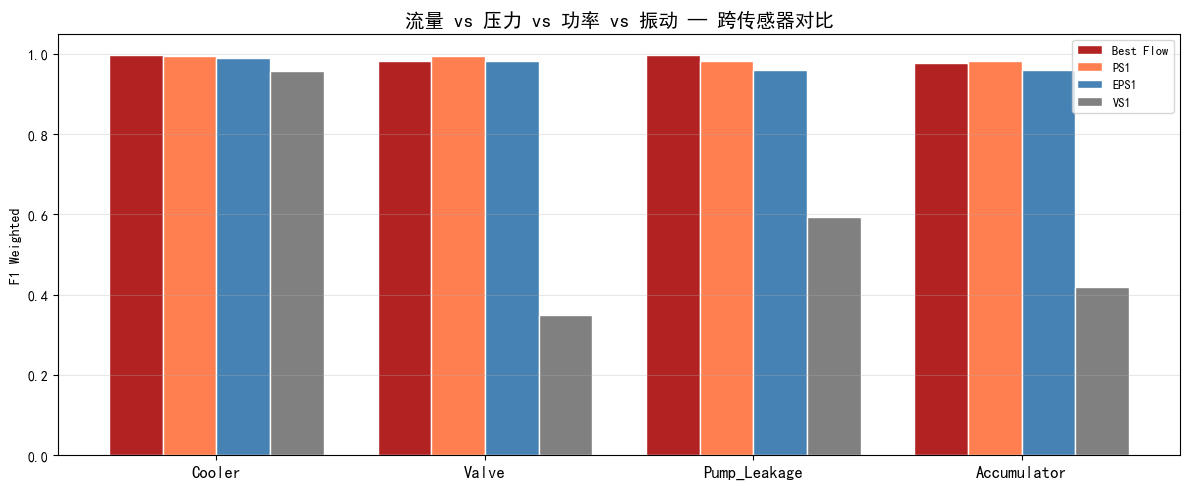

In [6]:
# Bar chart: 4 experiments × 4 faults
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(4)
w = 0.2
colors_exp = ['steelblue', 'gray', 'coral', 'firebrick']

for idx, (exp_name, exp_f1) in enumerate(all_results.items()):
    vals = [exp_f1[t] for t in target_config]
    ax.bar(x + idx*w, vals, w, label=exp_name, color=colors_exp[idx], edgecolor='white')

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(list(target_config.keys()), fontsize=12)
ax.set_ylabel('F1 Weighted')
ax.set_title('FS1 vs FS2 vs FS1+FS2 vs Full Fusion', fontsize=14)
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Cross-sensor comparison: Best flow vs PS1 vs EPS1 vs VS1
ps1_f1  = {'Cooler': 0.9932, 'Valve': 0.9932, 'Pump_Leakage': 0.9818, 'Accumulator': 0.9823}
eps1_f1 = {'Cooler': 0.9900, 'Valve': 0.9822, 'Pump_Leakage': 0.9590, 'Accumulator': 0.9604}
vs1_f1  = {'Cooler': 0.9559, 'Valve': 0.3500, 'Pump_Leakage': 0.5932, 'Accumulator': 0.4189}
best_flow_f1 = all_results['D: Full fusion']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(4)
w = 0.2
cross_data = [('Best Flow', best_flow_f1, 'firebrick'),
              ('PS1', ps1_f1, 'coral'),
              ('EPS1', eps1_f1, 'steelblue'),
              ('VS1', vs1_f1, 'gray')]
for idx, (name, f1_dict, color) in enumerate(cross_data):
    vals = [f1_dict[t] for t in target_config]
    ax.bar(x + idx*w, vals, w, label=name, color=color, edgecolor='white')
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(list(target_config.keys()), fontsize=12)
ax.set_ylabel('F1 Weighted')
ax.set_title('流量 vs 压力 vs 功率 vs 振动 — 跨传感器对比', fontsize=14)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 模块 4：原始波形分析（600 点，不降采样）
10 Hz = 600 点可直接画，这是 PS1-6/EPS1 做不到的。

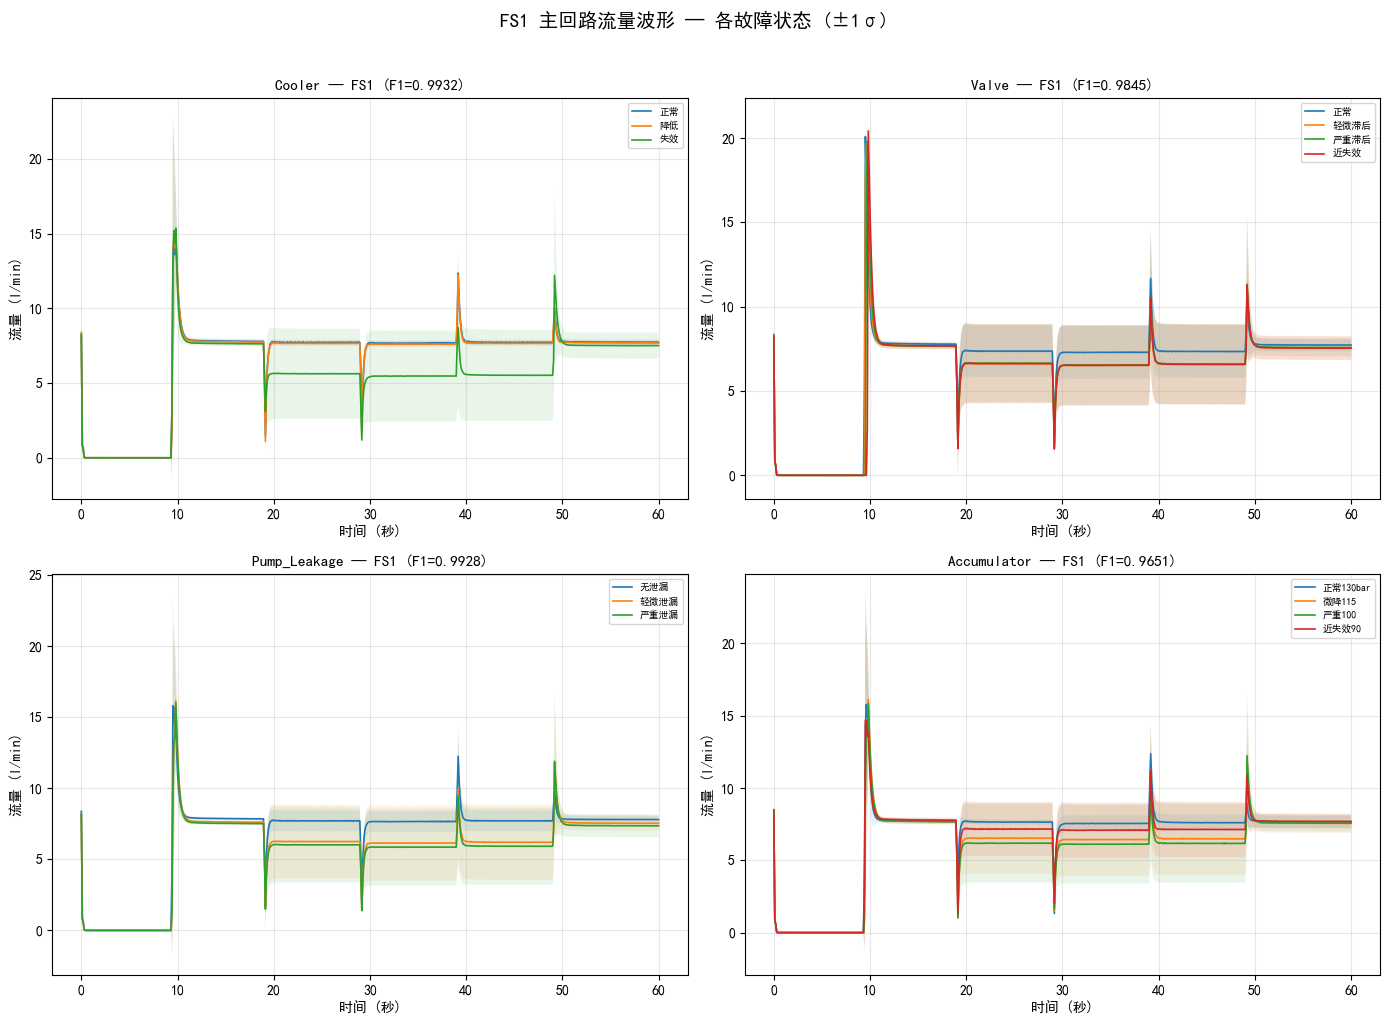

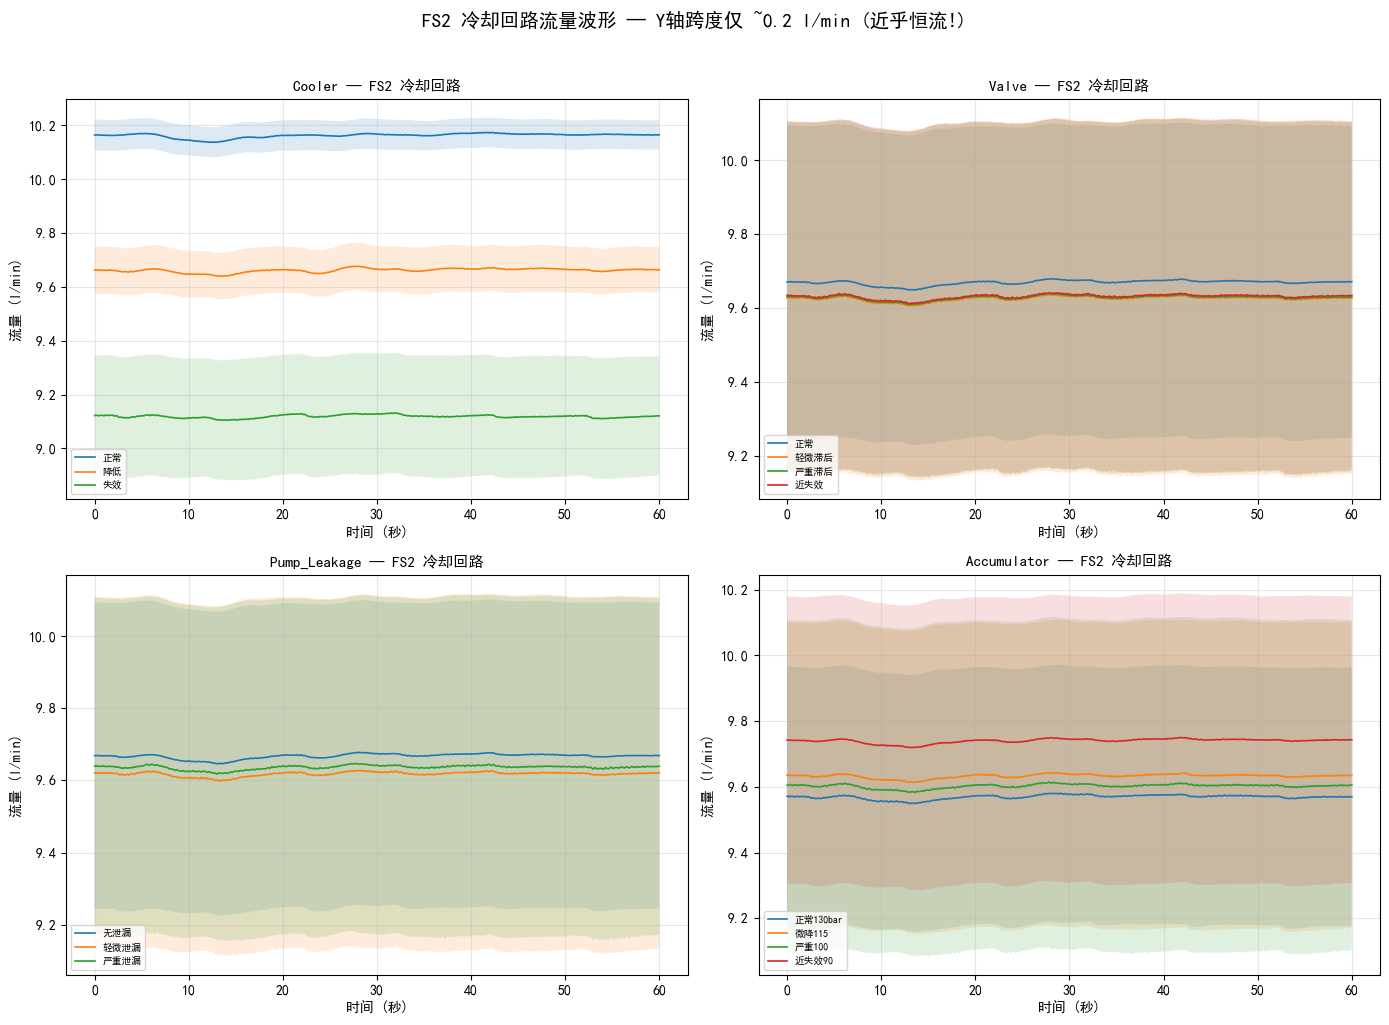

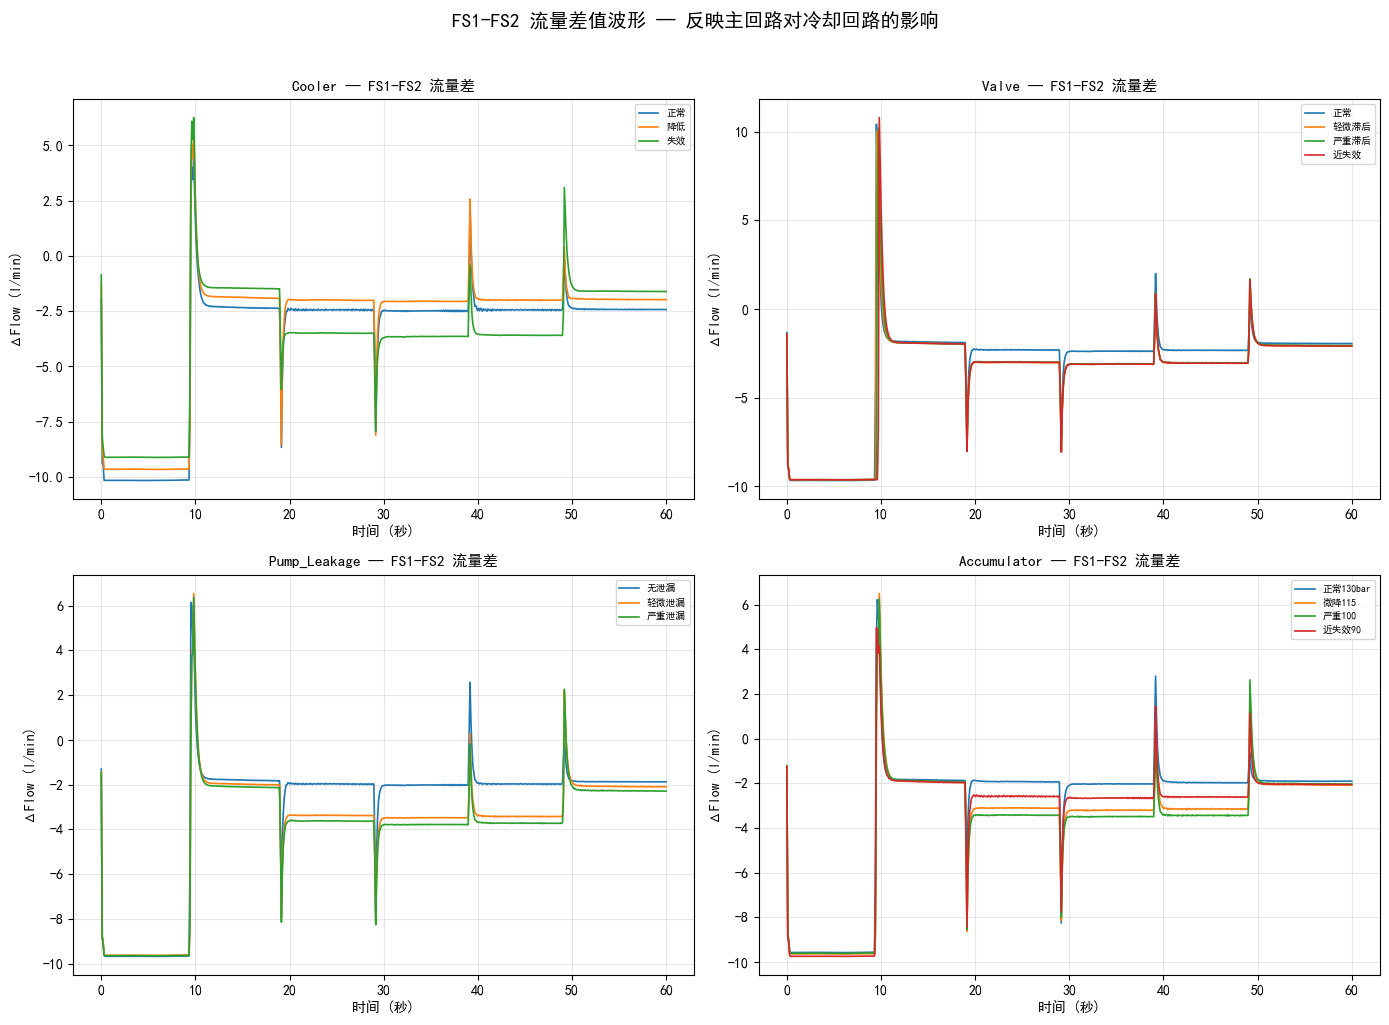

In [7]:
time_10hz = np.linspace(0, 60, 600)

# FS1 waveform by fault
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (fault_col, labels) in zip(axes.flat, fault_config.items()):
    ds = ds_curves['FS1'][fault_col]
    for state, name in labels.items():
        if state in ds:
            ax.plot(time_10hz, ds[state]['mean'], linewidth=1.2, label=name)
            ax.fill_between(time_10hz,
                            ds[state]['mean']-ds[state]['std'],
                            ds[state]['mean']+ds[state]['std'],
                            alpha=0.1)
    f1_val = all_results['A: FS1 only'][fault_col]
    ax.set_title(f'{fault_col} — FS1 (F1={f1_val:.4f})', fontsize=11)
    ax.set_xlabel('时间 (秒)')
    ax.set_ylabel('流量 (l/min)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('FS1 主回路流量波形 — 各故障状态 (±1σ)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# FS2 waveform — note the tiny Y-axis scale!
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (fault_col, labels) in zip(axes.flat, fault_config.items()):
    ds = ds_curves['FS2'][fault_col]
    for state, name in labels.items():
        if state in ds:
            ax.plot(time_10hz, ds[state]['mean'], linewidth=1.2, label=name)
            ax.fill_between(time_10hz,
                            ds[state]['mean']-ds[state]['std'],
                            ds[state]['mean']+ds[state]['std'],
                            alpha=0.15)
    ax.set_title(f'{fault_col} — FS2 冷却回路', fontsize=11)
    ax.set_xlabel('时间 (秒)')
    ax.set_ylabel('流量 (l/min)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('FS2 冷却回路流量波形 — Y轴跨度仅 ~0.2 l/min (近乎恒流!)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# FS1-FS2 difference waveform
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (fault_col, labels) in zip(axes.flat, fault_config.items()):
    ds = ds_curves['FS1-FS2'][fault_col]
    for state, name in labels.items():
        if state in ds:
            ax.plot(time_10hz, ds[state]['mean'], linewidth=1.2, label=name)
    ax.set_title(f'{fault_col} — FS1-FS2 流量差', fontsize=11)
    ax.set_xlabel('时间 (秒)')
    ax.set_ylabel('ΔFlow (l/min)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('FS1-FS2 流量差值波形 — 反映主回路对冷却回路的影响', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 模块 5：FS2 恒流稳定性分析（创新点）
FS2 是冷却回路，理应是恒流。**FS2 的 std 本身就是系统健康指标**——不依赖任何标签。


FS2 top-1% 异常周期 (n=23):
  Cooler: {3: np.int64(20), 100: np.int64(3)}
  Valve: {100: np.int64(16), 73: np.int64(3), 90: np.int64(3), 80: np.int64(1)}
  Pump_Leakage: {1: np.int64(12), 0: np.int64(7), 2: np.int64(4)}
  Accumulator: {100: np.int64(15), 90: np.int64(5), 130: np.int64(3)}


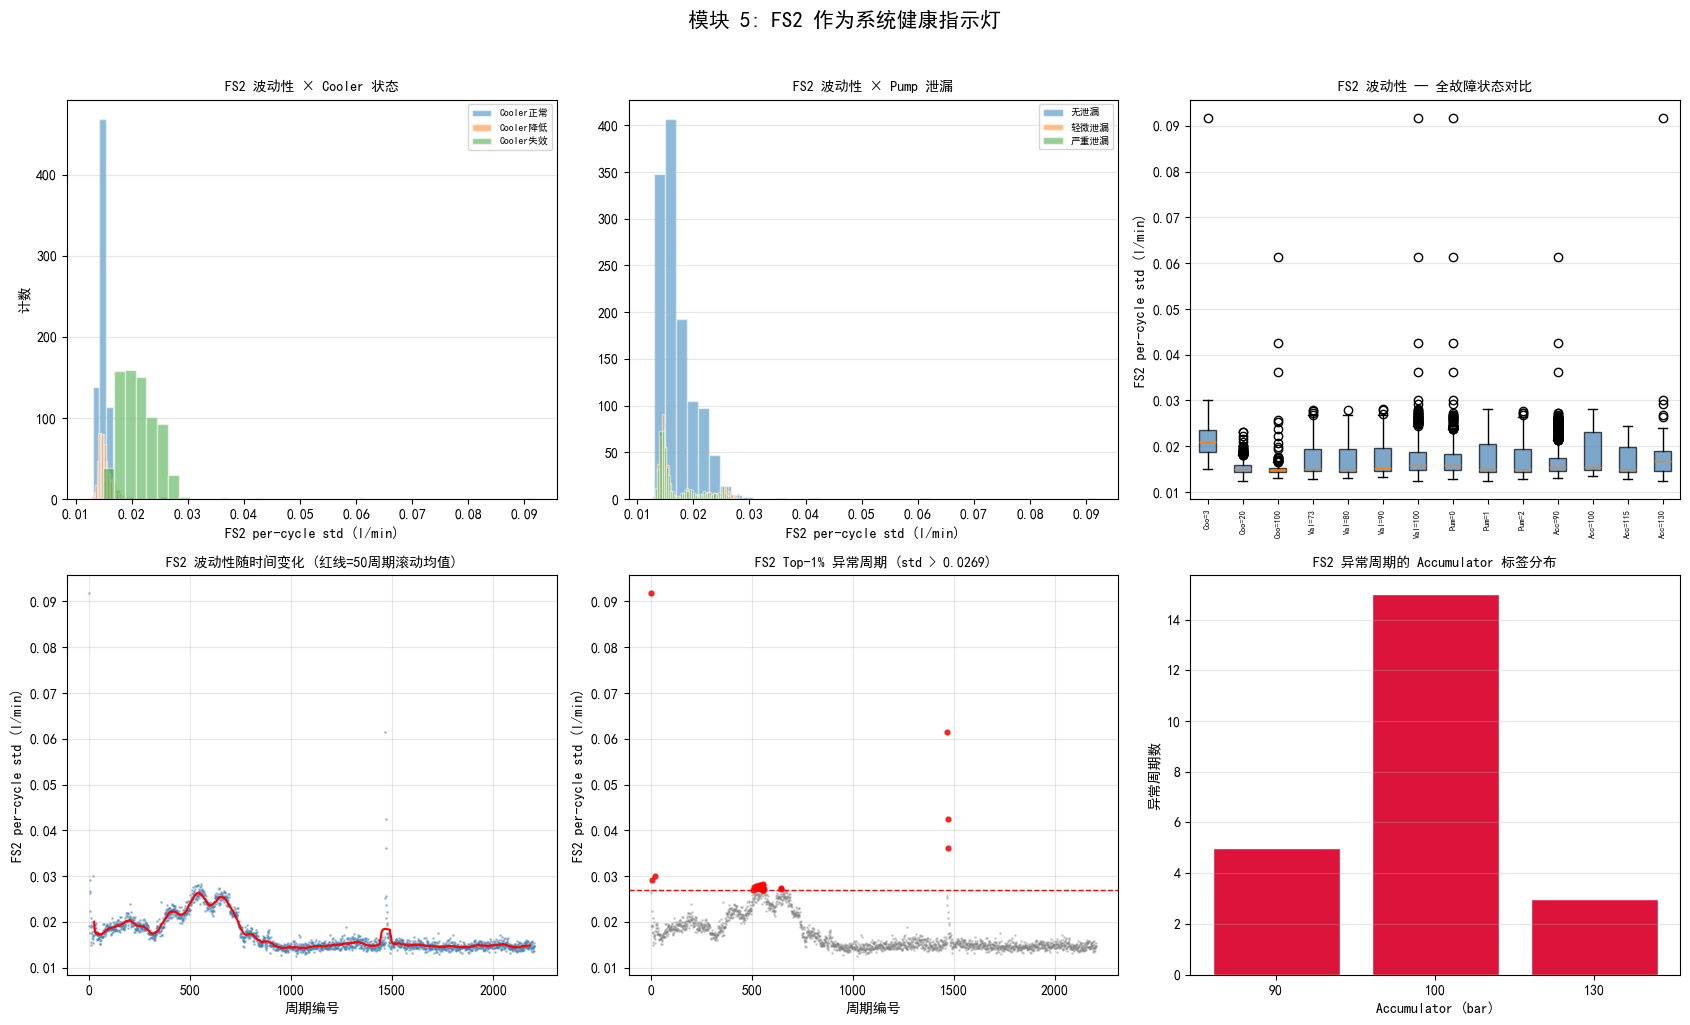

In [8]:
# FS2 per-cycle std as a free health indicator
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Plot 1: FS2 std histogram by Cooler state
for state, name in [(100, 'Cooler正常'), (20, 'Cooler降低'), (3, 'Cooler失效')]:
    mask = profile['Cooler'] == state
    axes[0,0].hist(fs2_std[mask], bins=40, alpha=0.5, label=name, edgecolor='white')
axes[0,0].set_xlabel('FS2 per-cycle std (l/min)')
axes[0,0].set_ylabel('计数')
axes[0,0].set_title('FS2 波动性 × Cooler 状态', fontsize=10)
axes[0,0].legend(fontsize=7)
axes[0,0].grid(True, alpha=0.3, axis='y')

# Plot 2: FS2 std histogram by Pump state
for state, name in [(0, '无泄漏'), (1, '轻微泄漏'), (2, '严重泄漏')]:
    mask = profile['Pump_Leakage'] == state
    axes[0,1].hist(fs2_std[mask], bins=40, alpha=0.5, label=name, edgecolor='white')
axes[0,1].set_xlabel('FS2 per-cycle std (l/min)')
axes[0,1].set_title('FS2 波动性 × Pump 泄漏', fontsize=10)
axes[0,1].legend(fontsize=7)
axes[0,1].grid(True, alpha=0.3, axis='y')

# Plot 3: FS2 std boxplot by all faults
box_data = []
box_labels_list = []
for fault_col in target_config:
    for state in target_config[fault_col]:
        mask = profile[fault_col] == state
        box_data.append(fs2_std[mask].values)
        box_labels_list.append(f'{fault_col[:3]}={state}')
bp = axes[0,2].boxplot(box_data, patch_artist=True, tick_labels=box_labels_list)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue'); patch.set_alpha(0.7)
axes[0,2].set_ylabel('FS2 per-cycle std (l/min)')
axes[0,2].set_title('FS2 波动性 — 全故障状态对比', fontsize=10)
axes[0,2].tick_params(axis='x', rotation=90, labelsize=6)
axes[0,2].grid(True, alpha=0.3, axis='y')

# Plot 4: FS2 std over time
axes[1,0].scatter(range(len(fs2_std)), fs2_std, s=1, alpha=0.4, c='steelblue')
rolling_std = pd.Series(fs2_std).rolling(window=50, center=True).mean()
axes[1,0].plot(range(len(fs2_std)), rolling_std, 'red', linewidth=1.5)
axes[1,0].set_xlabel('周期编号')
axes[1,0].set_ylabel('FS2 per-cycle std (l/min)')
axes[1,0].set_title('FS2 波动性随时间变化 (红线=50周期滚动均值)', fontsize=10)
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Top outliers — cycles with highest FS2 std
threshold = np.percentile(fs2_std, 99)
outlier_idx = np.where(fs2_std > threshold)[0]
axes[1,1].scatter(range(len(fs2_std)), fs2_std, s=1, alpha=0.3, c='gray')
axes[1,1].scatter(outlier_idx, fs2_std[outlier_idx], s=12, c='red', alpha=0.8, zorder=5)
axes[1,1].axhline(y=threshold, color='red', linestyle='--', linewidth=1)
axes[1,1].set_xlabel('周期编号')
axes[1,1].set_ylabel('FS2 per-cycle std (l/min)')
axes[1,1].set_title(f'FS2 Top-1% 异常周期 (std > {threshold:.4f})', fontsize=10)
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Outlier label distribution
if len(outlier_idx) > 0:
    outlier_labels = profile.iloc[outlier_idx]
    print(f'\nFS2 top-1% 异常周期 (n={len(outlier_idx)}):')
    for col in ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator']:
        vc = outlier_labels[col].value_counts()
        print(f'  {col}: {dict(vc)}')
    
    # Show outlier composition by Accumulator
    outlier_acc = outlier_labels['Accumulator'].value_counts().sort_index()
    axes[1,2].bar(outlier_acc.index.astype(str), outlier_acc.values, 
               color='crimson', edgecolor='white')
    axes[1,2].set_xlabel('Accumulator (bar)')
    axes[1,2].set_ylabel('异常周期数')
    axes[1,2].set_title(f'FS2 异常周期的 Accumulator 标签分布', fontsize=10)
    axes[1,2].grid(True, alpha=0.3, axis='y')

plt.suptitle('模块 5: FS2 作为系统健康指示灯', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 模块 6：频域分析
10 Hz → Nyquist=5 Hz。对比 FS1 (动态) vs FS2 (恒流) 的频谱。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


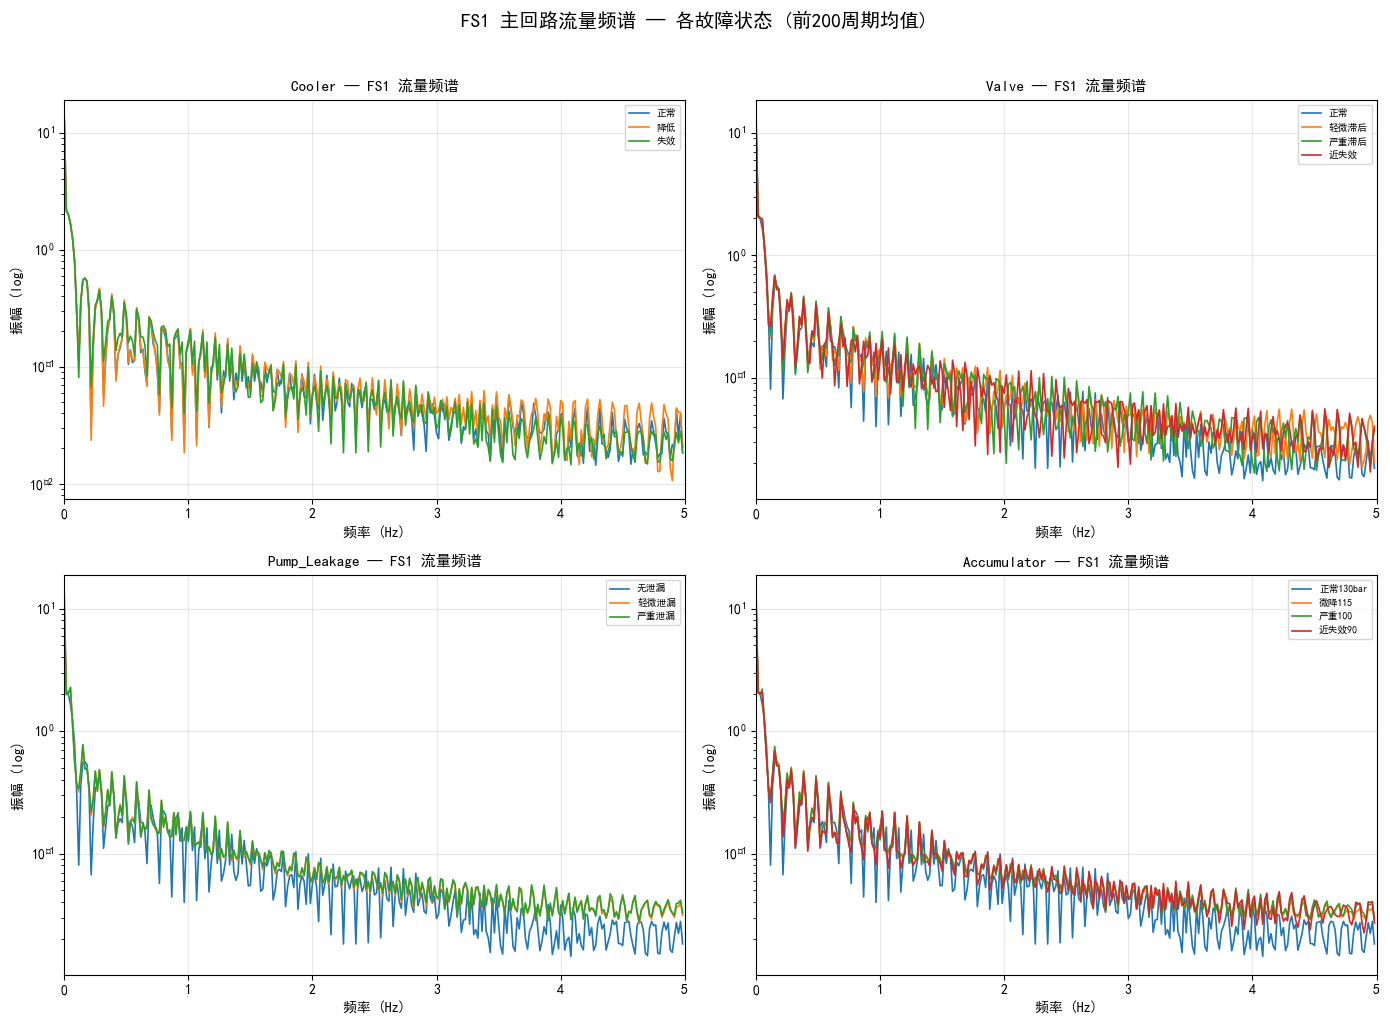

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


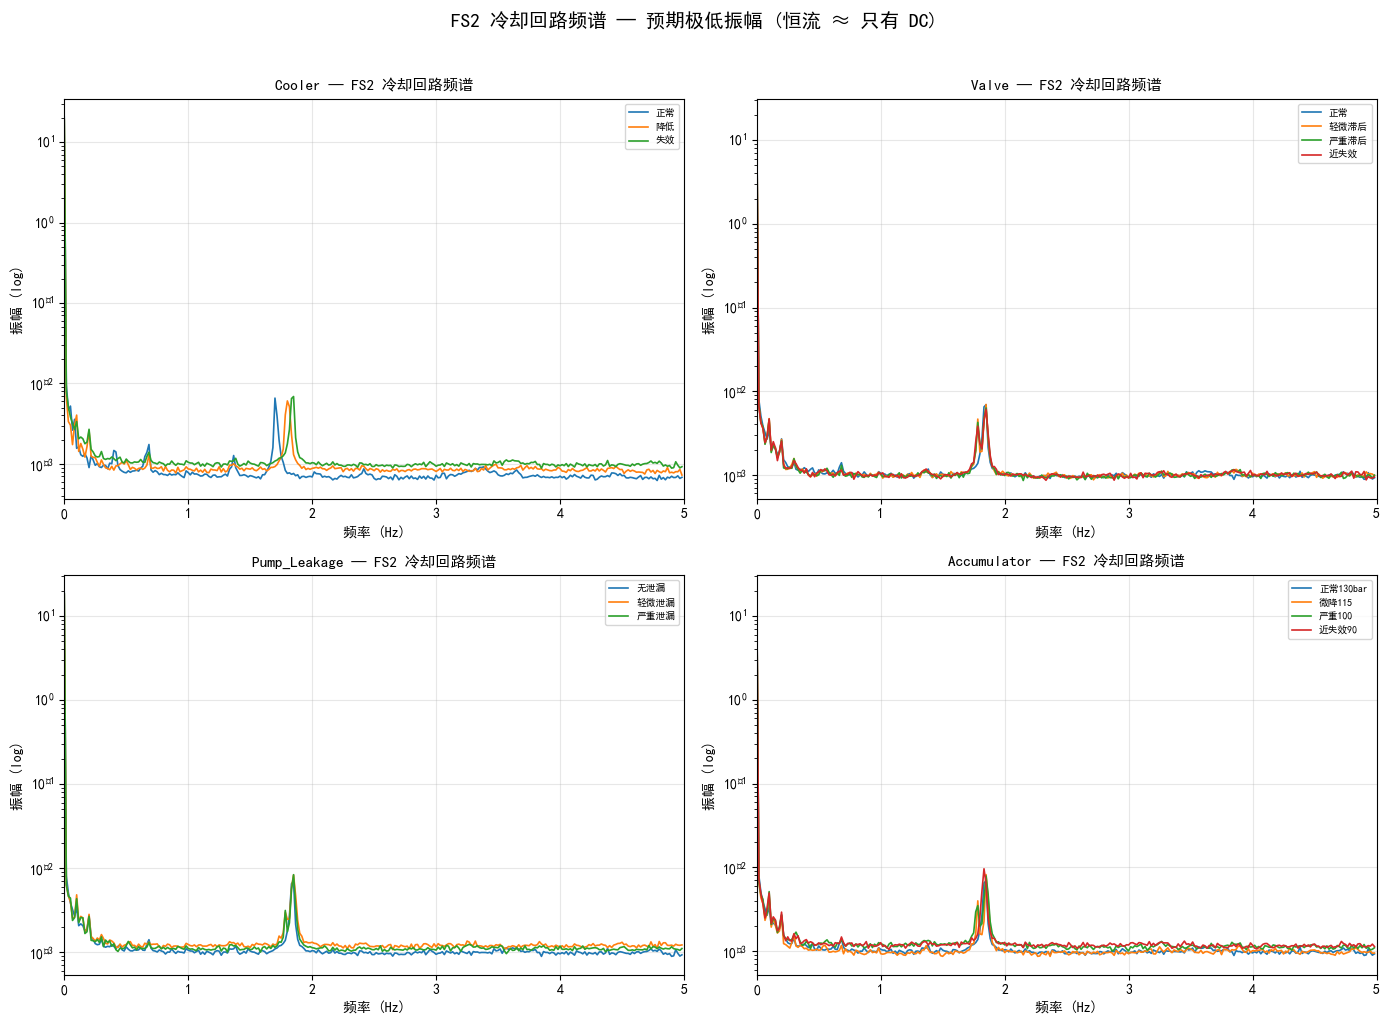

In [9]:
fs = 10
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# FS1 spectra
for ax, (fault_col, labels) in zip(axes.flat, fault_config.items()):
    for state, name in labels.items():
        mask = profile[fault_col] == state
        if mask.sum() > 0:
            samples = fs1[mask].iloc[:200]
            spectra = []
            for idx in range(len(samples)):
                x = samples.iloc[idx].values.astype(np.float64)
                n = len(x);
                yf = fft.fft(x); xf_full = fft.fftfreq(n, d=1/fs)
                half = n // 2
                amp = np.abs(yf[:half]) / n * 2
                spectra.append(amp)
            mean_spec = np.mean(spectra, axis=0)
            ax.semilogy(xf_full[:half], mean_spec, linewidth=1.2, label=name)
    ax.set_title(f'{fault_col} — FS1 流量频谱', fontsize=11)
    ax.set_xlabel('频率 (Hz)')
    ax.set_ylabel('振幅 (log)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 5)
plt.suptitle('FS1 主回路流量频谱 — 各故障状态 (前200周期均值)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# FS2 spectra (expect very flat — no dominant frequency)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (fault_col, labels) in zip(axes.flat, fault_config.items()):
    for state, name in labels.items():
        mask = profile[fault_col] == state
        if mask.sum() > 0:
            samples = fs2[mask].iloc[:200]
            spectra = []
            for idx in range(len(samples)):
                x = samples.iloc[idx].values.astype(np.float64)
                n = len(x);
                yf = fft.fft(x); xf_full = fft.fftfreq(n, d=1/fs)
                half = n // 2
                amp = np.abs(yf[:half]) / n * 2
                spectra.append(amp)
            mean_spec = np.mean(spectra, axis=0)
            ax.semilogy(xf_full[:half], mean_spec, linewidth=1.2, label=name)
    ax.set_title(f'{fault_col} — FS2 冷却回路频谱', fontsize=11)
    ax.set_xlabel('频率 (Hz)')
    ax.set_ylabel('振幅 (log)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 5)
plt.suptitle('FS2 冷却回路频谱 — 预期极低振幅 (恒流 ≈ 只有 DC)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 模块 7：物理量交叉验证 — 液压功率与系统效率
加载 PS1 + EPS1，算 FS1×PS1 液压功率 → 效率 = 液压功率 / 电机功率。

Hydraulic power range: [323, 1048] (l/min·bar)
Motor power range: [2362, 2741] W
Efficiency range: [0.1179, 0.4191]


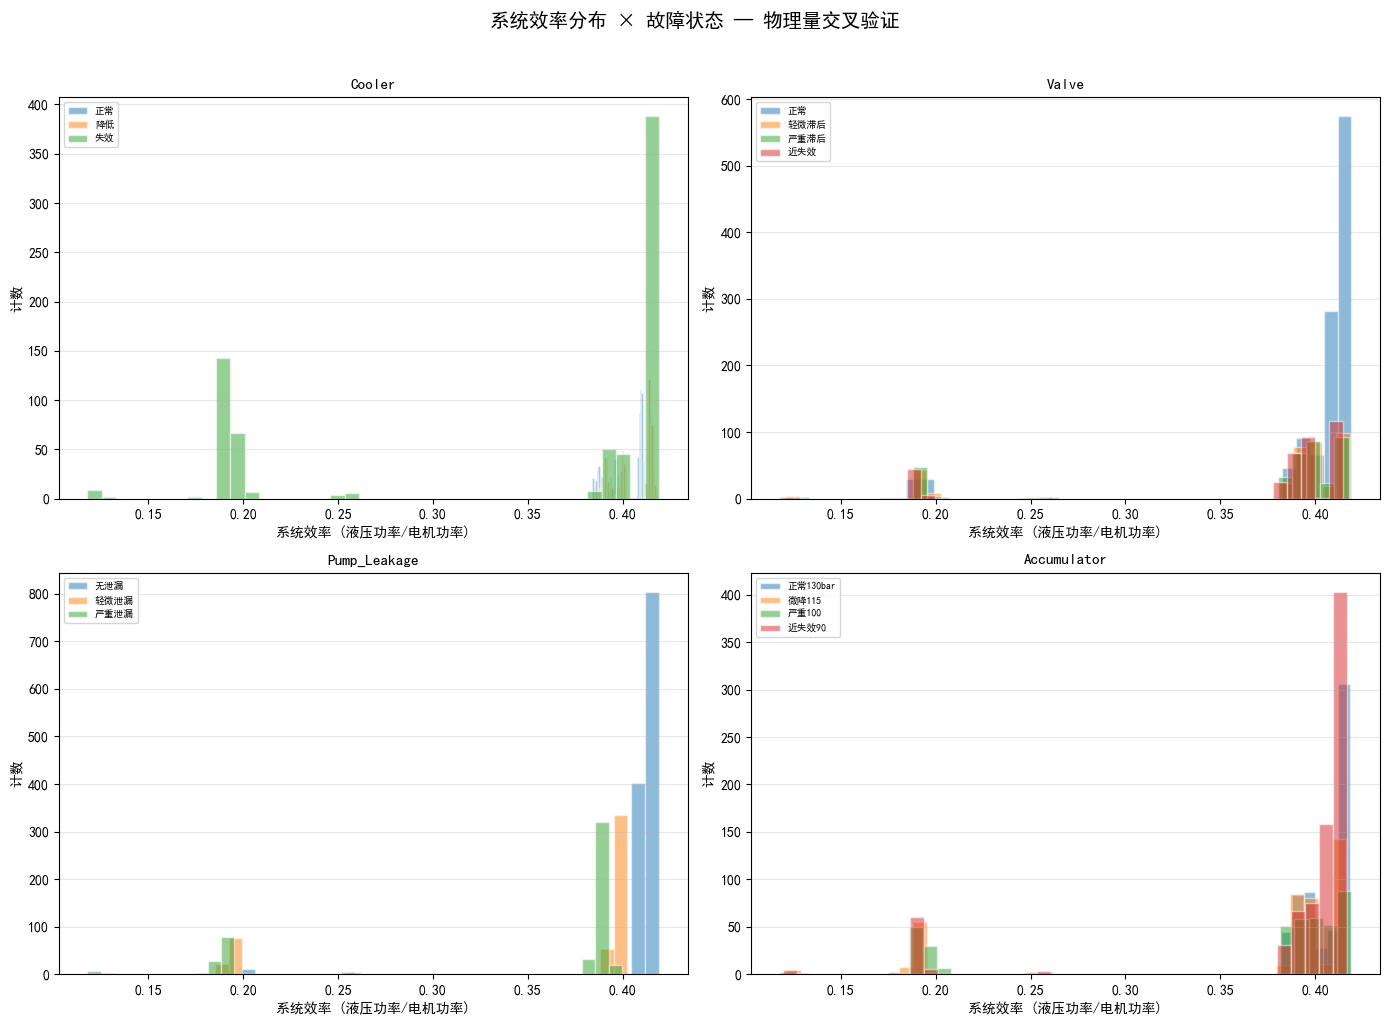


系统效率单变量故障诊断能力:


  Cooler        : F1=0.7265 (±0.0592) — 仅用效率一个特征!


  Valve         : F1=0.4152 (±0.0313) — 仅用效率一个特征!


  Pump_Leakage  : F1=0.9686 (±0.0231) — 仅用效率一个特征!


  Accumulator   : F1=0.3293 (±0.0654) — 仅用效率一个特征!


41662

In [10]:
# Recompute hydraulic power for plotting
ps1 = pd.read_csv(os.path.join(DATA_DIR, 'PS1.txt'), sep='\t', header=None)
ps1_ds = ps1.values.reshape(2205, 600, 10).mean(axis=2)
hyd_power_full = fs1.values.astype(np.float64) * ps1_ds

eps1 = pd.read_csv(os.path.join(DATA_DIR, 'EPS1.txt'), sep='\t', header=None)
eps1_ds = eps1.values.reshape(2205, 600, 10).mean(axis=2)

eff_per_cycle = hyd_power_full.mean(axis=1) / eps1_ds.mean(axis=1)

print(f'Hydraulic power range: [{hyd_power_full.mean(axis=1).min():.0f}, {hyd_power_full.mean(axis=1).max():.0f}] (l/min·bar)')
print(f'Motor power range: [{eps1_ds.mean(axis=1).min():.0f}, {eps1_ds.mean(axis=1).max():.0f}] W')
print(f'Efficiency range: [{eff_per_cycle.min():.4f}, {eff_per_cycle.max():.4f}]')

# Efficiency histogram by fault
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (fault_col, labels) in zip(axes.flat, fault_config.items()):
    for state, name in labels.items():
        mask = profile[fault_col] == state
        if mask.sum() > 0:
            ax.hist(eff_per_cycle[mask.values], bins=40, alpha=0.5, label=name, edgecolor='white')
    ax.set_xlabel('系统效率 (液压功率/电机功率)')
    ax.set_ylabel('计数')
    ax.set_title(f'{fault_col}', fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')
plt.suptitle('系统效率分布 × 故障状态 — 物理量交叉验证', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Efficiency as single-feature classifier
print('\n系统效率单变量故障诊断能力:')
for fault_col, classes in target_config.items():
    valid_mask = profile[fault_col].isin(classes).values
    X_1d = eff_per_cycle[valid_mask].reshape(-1, 1)
    y_raw = profile[fault_col].values[valid_mask]
    le = LabelEncoder()
    y_enc = le.fit_transform(y_raw)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_1d, y_enc, cv=5, scoring='f1_weighted')
    print(f'  {fault_col:<14}: F1={scores.mean():.4f} (±{scores.std():.4f}) — 仅用效率一个特征!')

del ps1, eps1, ps1_ds, eps1_ds, hyd_power_full; gc.collect()

## 模块 8：总结

In [11]:
print('=' * 68)
print('FS1 + FS2 流量传感器分析 — 总结')
print('=' * 68)
print()
print('1. 四组实验 F1 对比:')
print(f'   {"Experiment":<20} {"Cooler":<10} {"Valve":<10} {"Pump":<10} {"Acc":<10}')
print(f'   {"-"*60}')
for exp_name, exp_f1 in all_results.items():
    print(f'   {exp_name:<20} {exp_f1["Cooler"]:.4f}     {exp_f1["Valve"]:.4f}     {exp_f1["Pump_Leakage"]:.4f}     {exp_f1["Accumulator"]:.4f}')
print()
print('2. 跨传感器横向对比 (最佳流量模型 vs PS1 vs EPS1 vs VS1):')
print(f'   {"Fault":<16} {"BestFlow":<10} {"PS1":<10} {"EPS1":<10} {"VS1":<10}')
print(f'   {"-"*56}')
for t in target_config:
    print(f'   {t:<16} {all_results["D: Full fusion"][t]:.4f}     {ps1_f1[t]:.4f}     {eps1_f1[t]:.4f}     {vs1_f1[t]:.4f}')
print()
print('3. FS2 作为异常检测器:')
threshold_99 = np.percentile(fs2_std, 99)
n_outliers = (fs2_std > threshold_99).sum()
print(f'   - FS2 std 中位数: {fs2_std.median():.5f} l/min')
print(f'   - 99% 阈值: {threshold_99:.5f} l/min')
print(f'   - 异常周期数: {n_outliers} / {len(fs2_std)} ({n_outliers/len(fs2_std)*100:.2f}%)')
print()
print('4. 系统效率物理验证:')
print(f'   - 效率范围: [{eff_per_cycle.min():.4f}, {eff_per_cycle.max():.4f}]')
print(f'   - 效率作为单变量诊断能力 (见模块7)')
print()
print('5. 关键发现:')
for t in target_config:
    if all_results['D: Full fusion'][t] > ps1_f1[t]:
        print(f'   ★ 流量超越压力! {t}: Flow={all_results["D: Full fusion"][t]:.4f} > PS1={ps1_f1[t]:.4f}')
gain_vs_fs1 = all_results['D: Full fusion']['Pump_Leakage'] - all_results['A: FS1 only']['Pump_Leakage']
print(f'   - 差值+物理特征对 Pump 的增益: {gain_vs_fs1:+.4f}')
if 'B: FS2 only' in all_results:
    print(f'   - FS2 仅30特征也能做到 F1={all_results["B: FS2 only"]["Cooler"]:.4f} (Cooler) — 恒流回路也有信息!')
print()
print('=' * 68)
print('Analysis complete.')

FS1 + FS2 流量传感器分析 — 总结

1. 四组实验 F1 对比:
   Experiment           Cooler     Valve      Pump       Acc       
   ------------------------------------------------------------
   A: FS1 only          0.9932     0.9845     0.9928     0.9651
   B: FS2 only          0.9855     0.5149     0.6893     0.7736
   C: FS1+FS2           0.9959     0.9845     0.9959     0.9800
   D: Full fusion       0.9968     0.9827     0.9959     0.9773

2. 跨传感器横向对比 (最佳流量模型 vs PS1 vs EPS1 vs VS1):
   Fault            BestFlow   PS1        EPS1       VS1       
   --------------------------------------------------------
   Cooler           0.9968     0.9932     0.9900     0.9559
   Valve            0.9827     0.9932     0.9822     0.3500
   Pump_Leakage     0.9959     0.9818     0.9590     0.5932
   Accumulator      0.9773     0.9823     0.9604     0.4189

3. FS2 作为异常检测器:
   - FS2 std 中位数: 0.01546 l/min
   - 99% 阈值: 0.02686 l/min
   - 异常周期数: 23 / 2205 (1.04%)

4. 系统效率物理验证:
   - 效率范围: [0.1179, 0.4191]
   - 效率作为单变量诊断能力